In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import importlib
import os
import cmcrameri.cm as cmc
from scipy.signal import stft
from scipy.signal import windows

import superlets_package.superlets_emg as superlets
import superlets_package.auxiliar_functions as aux
import superlets_package.cwt as cwt_new

sys.path.insert(0, '..')
print(sys.path)

['..', '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina', '/Users/neuralrehabilitationgroup/PycharmProjects/SingularSuperletPY', '/opt/anaconda3/envs/Superlets-Marina/lib/python38.zip', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8/lib-dynload', '', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8/site-packages', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8/site-packages/setuptools/_vendor']


In [2]:
importlib.reload(aux)

<module 'superlets_package.auxiliar_functions' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/auxiliar_functions.py'>

In [3]:
importlib.reload(superlets)

<module 'superlets_package.superlets_original' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/superlets_original.py'>

In [4]:
importlib.reload(cwt_new)

<module 'superlets_package.cwt' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/cwt.py'>

In [5]:
fontsize_title = 10
fontsize_subtitle = 16
fontsize_ticks = 12
fontsize_labels = 14
fontsize_legend = 14

In [6]:
save = True

if save:
    folder_out = "/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/RESULTS/NEW_SLT"
    new_folder_path = os.path.join(folder_out, 'REAL_EMG')
    os.makedirs(new_folder_path, exist_ok=True)

# Load EMG signal

In [7]:
folder_out = "/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/RESULTS/REAL_SIGNAL"
data = pd.read_csv(os.path.join(folder_out,'real_signal.csv'))
emg = data['Sol_r']
array_np = emg.values 
# # Put the signal in mV
emg = np.array(array_np) * 1000

# Obtain only one burst
# if len(emg) > 12000:
#     emg = emg[11000:12000]
fs = 2000
signal_duration = len(emg)/fs
t = np.linspace(0, len(emg)/fs, len(emg))

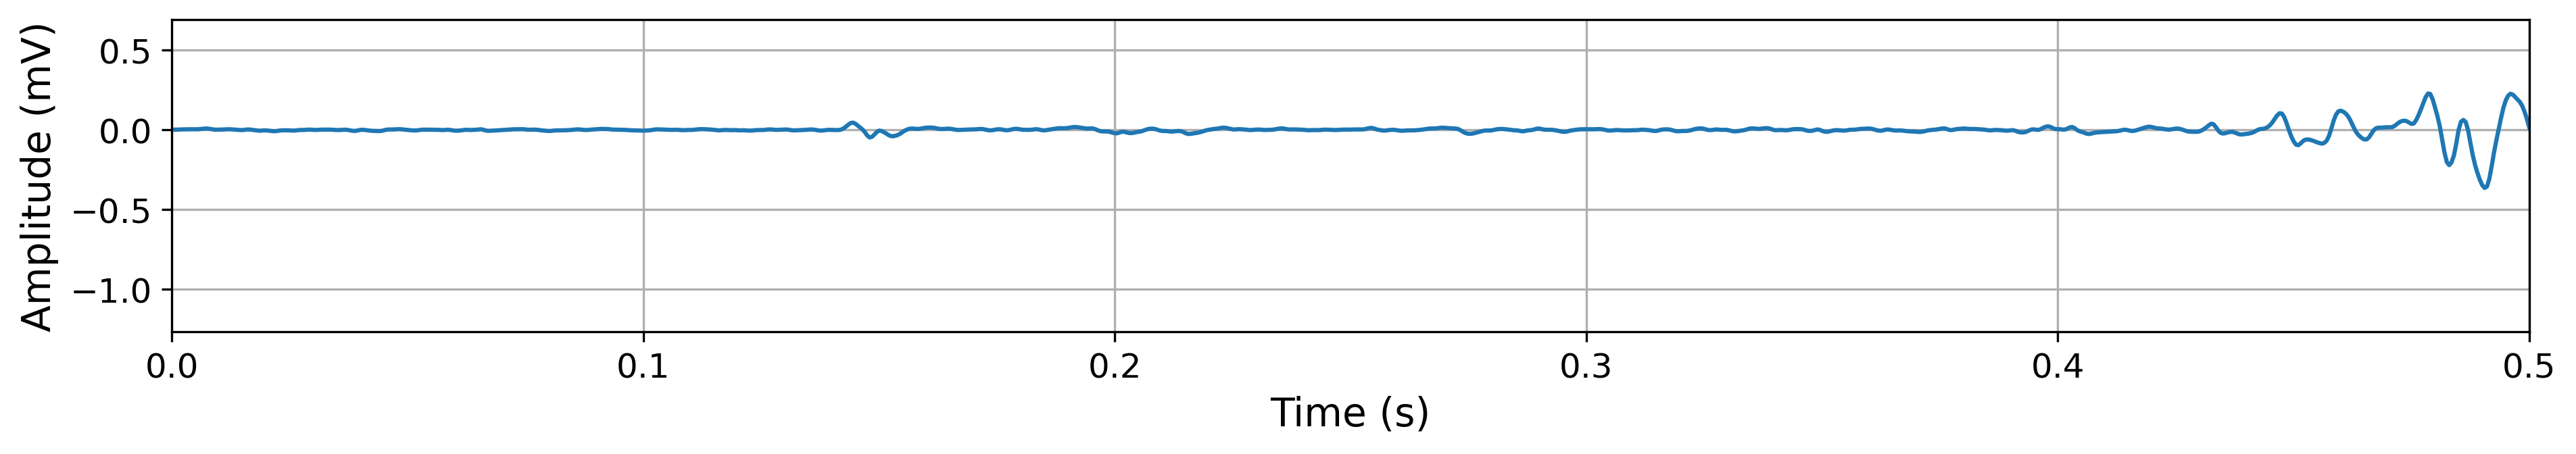

In [8]:
fig, ax = plt.subplots(figsize=(15, 2), dpi=300)
ax.set_xlabel("Time (s)", fontsize=fontsize_labels)
ax.set_ylabel("Amplitude (mV)", fontsize=fontsize_labels)
ax.set_xlim(0,0.5)
# ax.set_ylim(-1,1)

ax.plot(np.linspace(0, len(emg)/fs, len(emg)), emg)

ax.tick_params(axis='both', labelsize=fontsize_ticks)
ax.grid(True)

if save:
    fig.savefig(os.path.join(new_folder_path,"emg.png"), dpi=300, bbox_inches="tight")

Resolución de frecuencia lograda (Delta f): 0.09 Hz


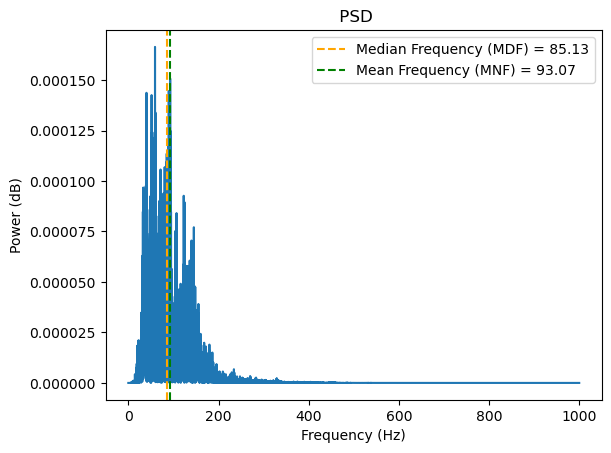

In [9]:
psd_welch, f_welch, MNF = aux.periodograma_max_res(emg, fs, plot=True)
MNF_1 = [MNF]

In [10]:
freqs = np.linspace(10,500,int(fs/2))

# Continuous Wavelet Transform

In [16]:
plot_tf_representation = True

In [17]:
params_wavelet = [100,130,230]

KeyboardInterrupt: 

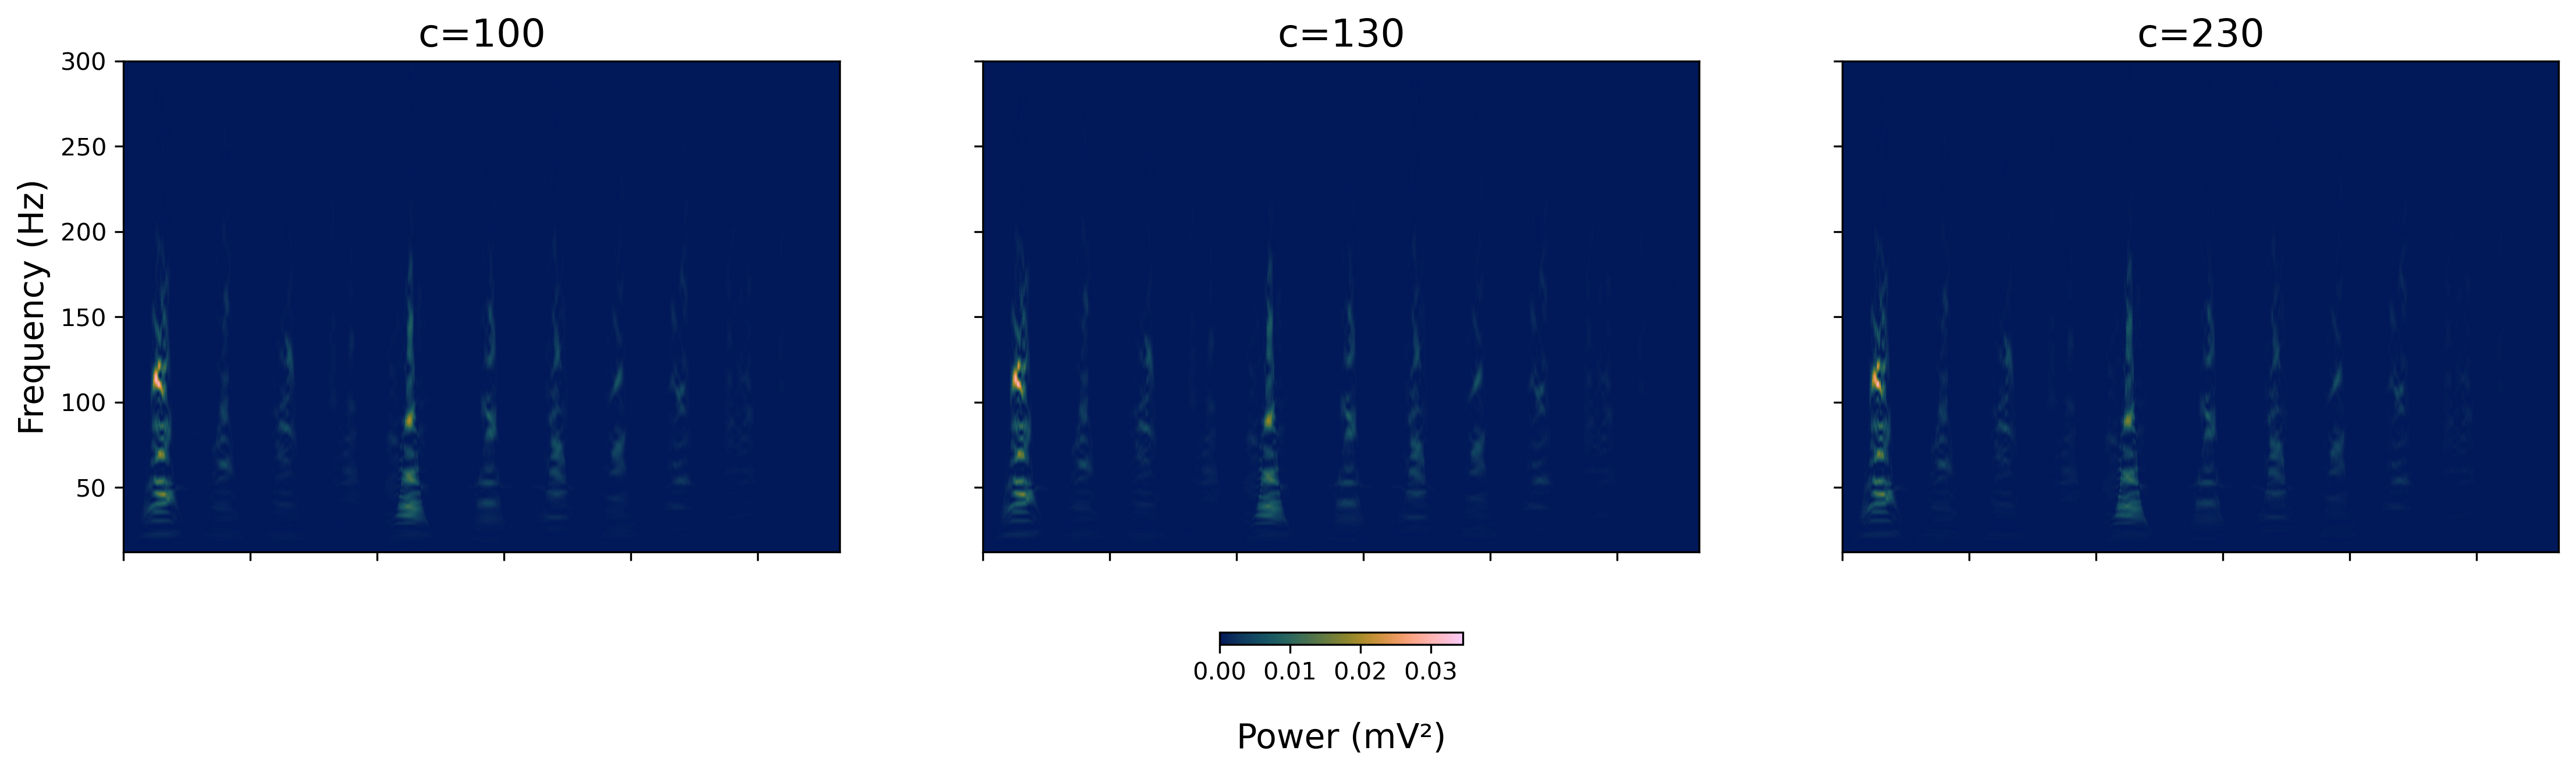

In [18]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(params_wavelet), figsize=(18,5), dpi=300, sharey=True, sharex=True)

for i, c in enumerate(params_wavelet):
    wavelet = f'cmor{c}-1.0'
    cwtmatr, f_cwt, physical_freqs = cwt_new.wavelet_transform(emg,wavelet,freqs,fs)
    scalogram_cwt = np.abs(cwtmatr)**2
    
    if plot_tf_representation:
        f_min = 10
        f_max = 300
        mask = (freqs >= 10) & (freqs <= 300)
        
        pcm = ax[i].pcolormesh(t, f_cwt[mask], scalogram_cwt[mask,:], shading='gouraud', cmap=cmc.batlow)
        
        ax[i].set_title(f'c={c}', fontsize=fontsize_subtitle)
        if i == 0:
            ax[i].set_ylabel('Frequency (Hz)', fontsize=fontsize_labels)
        else:
            ax[i].set_ylabel('')
        
        ax[i].set_ylim(f_cwt[0], f_max)
        ax[i].tick_params(axis='x', labelbottom=False, bottom=True) 
        
if plot_tf_representation: 
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.12, shrink=0.1)
    
    cbar.set_label('Power (mV²)', rotation=0, labelpad=15, fontsize=fontsize_labels)
        
if save:
    fig.savefig(os.path.join(new_folder_path,"scalogram_cwt.png"), dpi=300, bbox_inches="tight")
    

# Superlet Transform

In [ ]:
params_superlet = [[3, 5, 1], [1, 1, 5], [30, 30, 40]]
# params_superlet = [[2],[3],[220]]

In [ ]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(params_superlet), figsize=(18,5), dpi=300, sharey=True, sharex=True)

for (i, (base_cycle, min_order, max_order)) in enumerate(zip(*params_superlet)):
    print(f'{i+1} parameter')
    # out = superlet_new.superlets(emg, fs, freqs,base_cycle, [min_order, max_order])
    # scalogram = out
    
    scalogram_slt = superlets.adaptive_superlet_transform(emg, freqs, sampling_freq=fs,
                                                         base_cycle=base_cycle, min_order=min_order,
                                                         max_order=max_order, mode="mul")
    if plot_tf_representation:
        im = ax[i].imshow(scalogram_slt[mask,:], aspect='auto', cmap=cmc.batlow, interpolation="none", origin="lower",extent=[0, len(emg)/fs, freqs[mask][0], freqs[mask][-1]])
        ax[i].set_title(f"$c_1$: {base_cycle}, o: {min_order}-{max_order}", fontsize=fontsize_subtitle)
        ax[i].set_xlabel("Time (s)", fontsize=fontsize_labels)
        if i == 0:
            ax[i].set_ylabel("Frequency (Hz)", fontsize=fontsize_labels)
        else:
            ax[i].set_ylabel("")
        ax[i].set_ylim(f_min, f_max)
        ax[i].grid(False)
    
if plot_tf_representation:
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    cbar.set_label('Power (V²)', rotation=0, labelpad=15)
        
if save:
    fig.savefig(os.path.join(new_folder_path,"scalogram_slt.png"), dpi=300, bbox_inches="tight")
    

# Short-Time Fast-Fourier Transform

In [15]:
windows_ms = [25, 650, 1000]

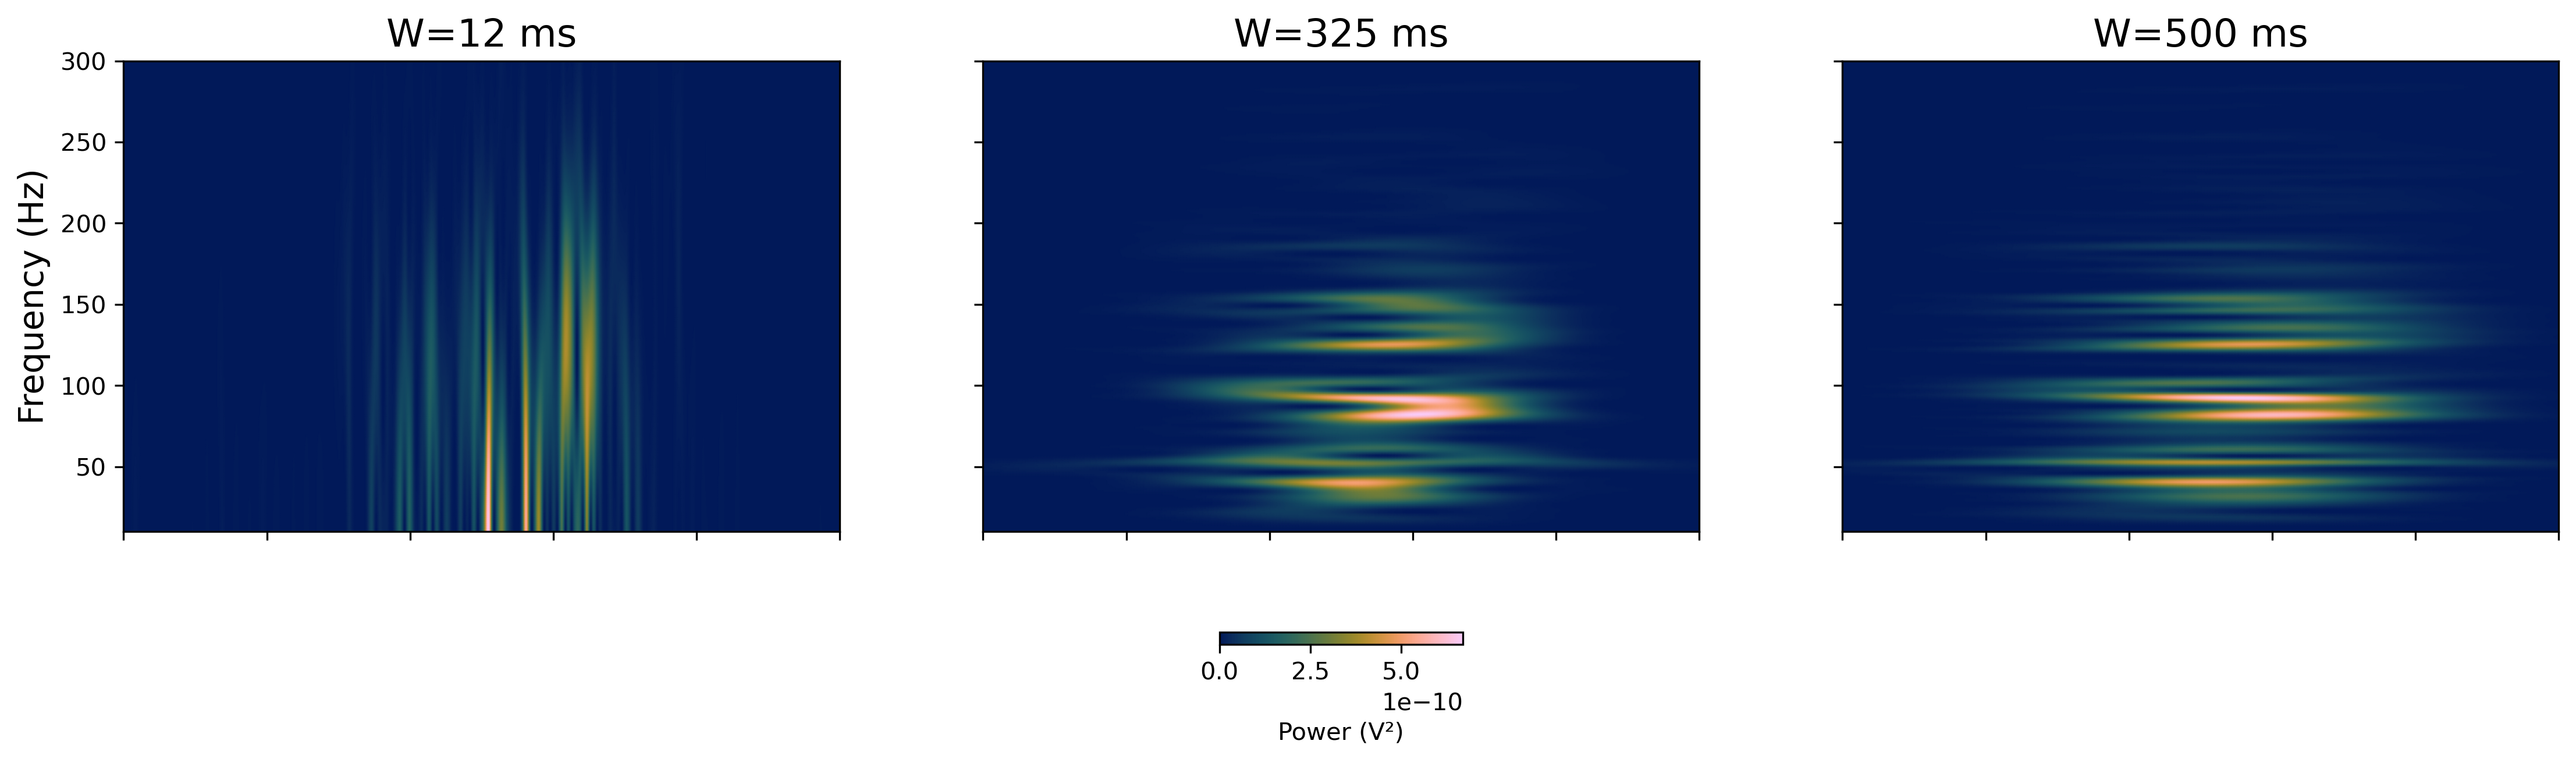

In [16]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(windows_ms), figsize=(18,5), dpi=300, sharey=True, sharex=True) 
    
for i, w in enumerate(windows_ms):
    window = windows.blackman(w)
    
    nfft = 2 * (len(freqs))

    f_stft, t_stft, Zxx = stft(emg, fs=fs, window='blackman', nperseg=w, noverlap=w-1, nfft=nfft, detrend=False, return_onesided=True, boundary='zeros', padded=True, axis=-1, scaling='spectrum')

    spectrogram = np.abs(Zxx) ** 2
    
    if plot_tf_representation:
        pcm = ax[i].pcolormesh(t_stft, f_stft, spectrogram, shading='gouraud', cmap=cmc.batlow)
        
        ax[i].set_title(f'W={w * 1000 // fs} ms', fontsize=fontsize_subtitle)
        if i == 0:
            ax[i].set_ylabel('Frequency (Hz)', fontsize=fontsize_labels)
        else: 
            ax[i].set_ylabel('')
        # ax[i].set_xlabel('Time [s]')

        ax[i].set_ylim(10, 300)
        
        ax[i].tick_params(axis='x', labelbottom=False, bottom=True)  # oculta etiquetas, deja palitos

if plot_tf_representation:
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.1)
    cbar.set_label('Power (V²)', rotation=0, labelpad=15)
    
if save:
    fig.savefig(os.path.join(new_folder_path,"spectrogram_stft.png"), dpi=300, bbox_inches="tight")
    